<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Convolutional Neural Network (CNN) - Image classification - CIFAR10 dataset**
---

![image](https://corochann.com/wp-content/uploads/2021/09/cifar10_plot_more-700x700-1.png)

### **Context**

In this study, we will build neural network with CNN to classify image of objects in Cifar-10 dataset.


### **About CIFAR-10 dataset**

CIFAR-10 contains:

* 60,000 color images

* 32 × 32 pixels

* 3 color channels (RGB)

* 10 object classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)

![image](https://www.researchgate.net/profile/Abien-Fred-Agarap/publication/337731039/figure/fig3/AS:832268801171466@1575439753171/Figure-from-9-The-CIFAR-10-dataset-is-a-benchmark-image-classification-dataset-with-10.ppm)

### **Convolutional Neural Network (CNN)**

The CNN model is a type of deep neural network designed primarily for processing grid-structured data such as images. It uses convolutional layers to automatically extract spatial features (e.g., edges, textures, shapes) through local connections and shared weights, making it more efficient than fully connected networks for visual tasks.

**Initial setup**

In [1]:
# Importing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, GlobalAveragePooling2D, MaxPooling2D
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# style
plt.style.use('ggplot')

**Loading dataset**

In [2]:
# Loading dataset of CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


**Checking data shape**

In [3]:
# Train data
X_train.shape

(50000, 32, 32, 3)

In [4]:
# Test data
X_test.shape

(10000, 32, 32, 3)

So, 50000 data will be used as training images and 10000 data will be used as testing images. The image width will be 32 x 32 (pixels). The last score of 3 represents the RGB color.

**Verifying the data**

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:

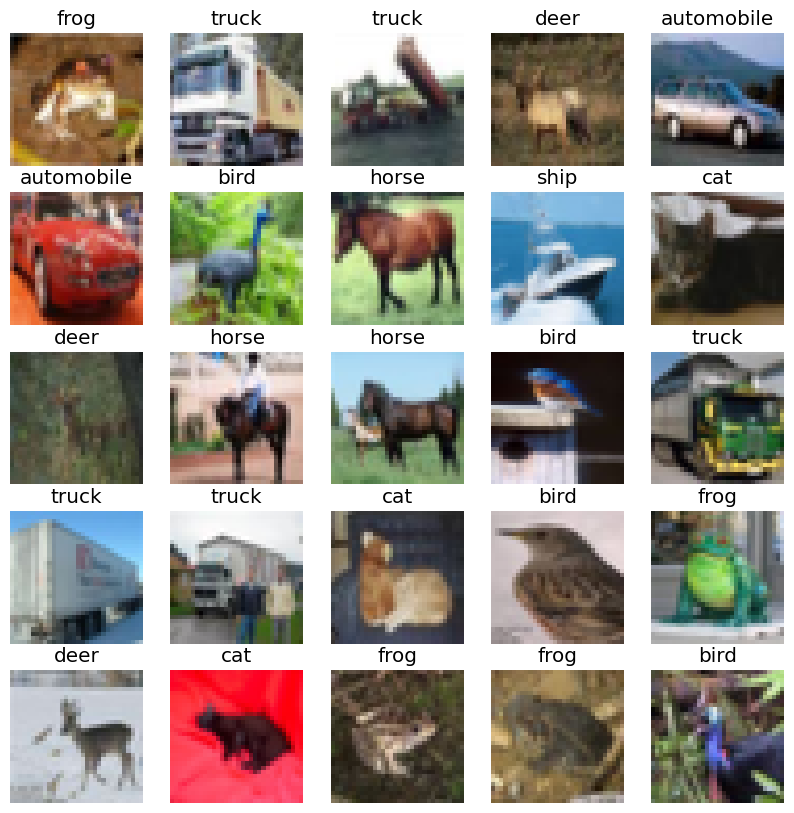

In [5]:
# Verifying the data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Displaying six images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    # The CIFAR labels happen to be arrays, # we need the extra index
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

### **Data Preprocessing**

In [6]:
# Data normalisation

# Normalize pixel values to be between 0 and 1
X_train = X_train/255.0
X_test = X_test/255.0

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
es_cb = EarlyStopping(monitor='val_loss', patience=5)
md_cb = ModelCheckpoint(filepath='best_model.keras', save_best_only=True)

In [8]:
# Create a simple CNN model architecture for CIFAR-10 (32x32x3 input)

# Setting sequential model
model = Sequential(name='CNN4CIFAR')

# First Convolution Block and input layer
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))

# Fourth Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Fifth Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(GlobalAveragePooling2D())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer (CIFAR-10 has 10 output classes)
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "CNN4CIFAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 416,650 (1.59 MB)

 Trainable params: 416,650 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### **Model training**

In [10]:
# Train the model

historyCNN = model.fit(X_train,
                       y_train,
                       epochs=20,
                       validation_split=0.2,
                       callbacks=[es_cb, md_cb])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.3738 - loss: 1.6596 - val_accuracy: 0.5131 - val_loss: 1.3312
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5602 - loss: 1.2091 - val_accuracy: 0.6101 - val_loss: 1.0929
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6346 - loss: 1.0255 - val_accuracy: 0.6470 - val_loss: 1.0083
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6834 - loss: 0.8925 - val_accuracy: 0.6714 - val_loss: 0.9143
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7219 - loss: 0.7831 - val_accuracy: 0.7178 - val_loss: 0.8187
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7531 - loss: 0.7046 - val_accuracy: 0.7311 - val_loss: 0.7775
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7776 - loss: 0.6393 - val_accuracy: 0.7239 - val_loss: 0.7914
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7959 - loss: 0.5785 -

### **Model evaluation**

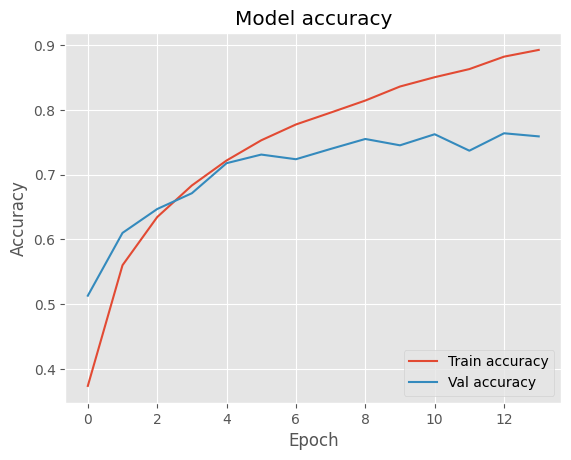

In [11]:
# Plotting accuracy
plt.plot(historyCNN.history['accuracy'])
plt.plot(historyCNN.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train accuracy', 'Val accuracy'], loc='lower right')
plt.show()

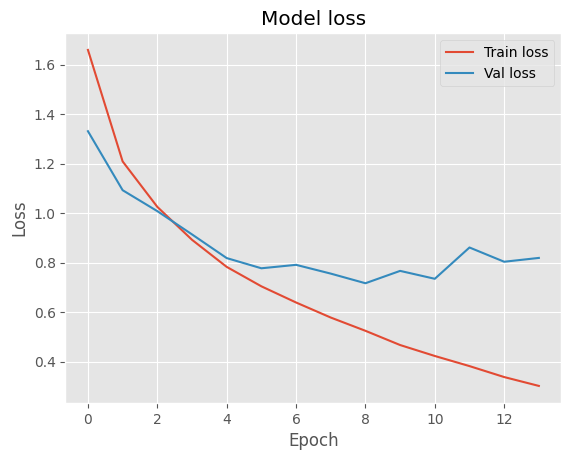

In [12]:
# Plotting loss
plt.plot(historyCNN.history['loss'])
plt.plot(historyCNN.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train loss', 'Val loss'], loc='upper right')
plt.show()

In [13]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras')
loss, accuracy = best_model.evaluate(X_test, y_test)
print(f'accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7563 - loss: 0.7363
accuracy: 0.7562999725341797


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


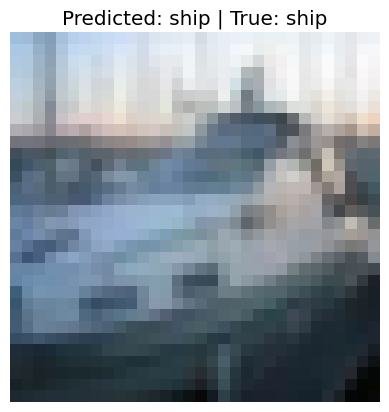

In [14]:
# Prediction and display result
predictions = model.predict(X_test)

sample_index = 2
predicted_class = np.argmax(predictions[sample_index])
true_class = y_test[sample_index][0]

plt.imshow(X_test[sample_index])
plt.title(f"Predicted: {class_names[predicted_class]} | True: {class_names[true_class]}")
plt.axis("off")
plt.show()

### **Conclusion**

We have 75.6% accuracy. This CNN result is better than the result of [previous work](https://github.com/harishmuh/Deep-Learning_study/blob/main/DNN_CIFAR10.ipynb) with DNN model (about 40% accuracy). However, we may need to improve the model to further increase the accuracy.